In [1]:
import random

# Imports

import helpers.helper_functions as hf
import mne
import os.path as op
from mne.channels import combine_channels
import pandas as pd
from mne.beamformer import make_lcmv, apply_lcmv_epochs
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import hilbert
import helpers.test_circ_plot as circ_plot


ss = hf.settings_dict()

In [2]:
event_id = 4
event_name = str(event_id)
duty_cycle = ss['event_name_list'][event_id-1]
trial = 4

loading dataset for subject:  0005_3SJ


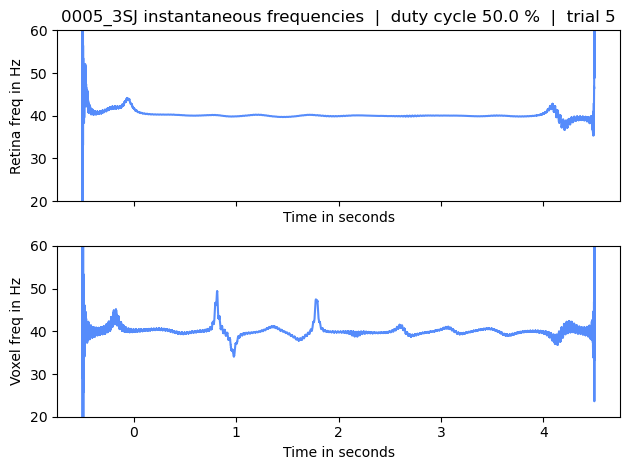

loading dataset for subject:  0002_TCZ


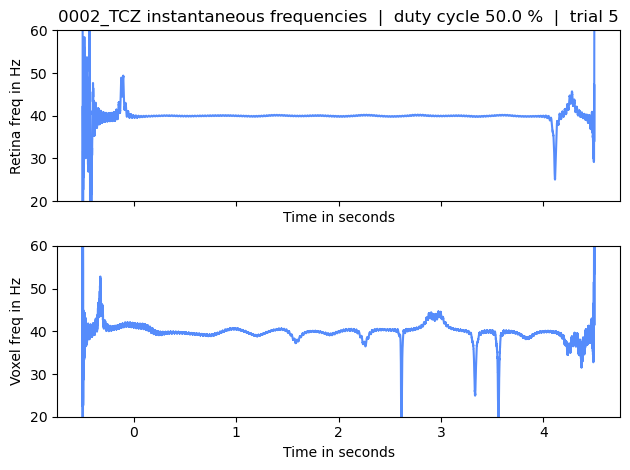

loading dataset for subject:  0009_YGZ


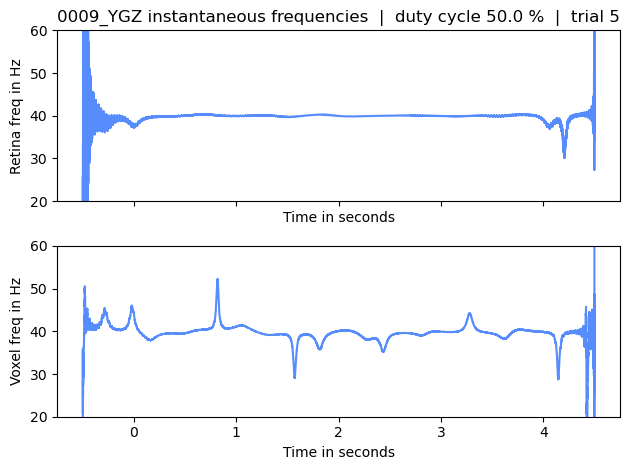

loading dataset for subject:  0010_ZMG


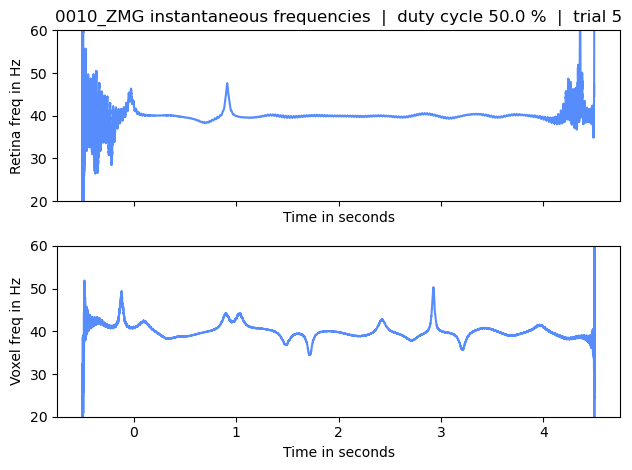

loading dataset for subject:  0011_MEE


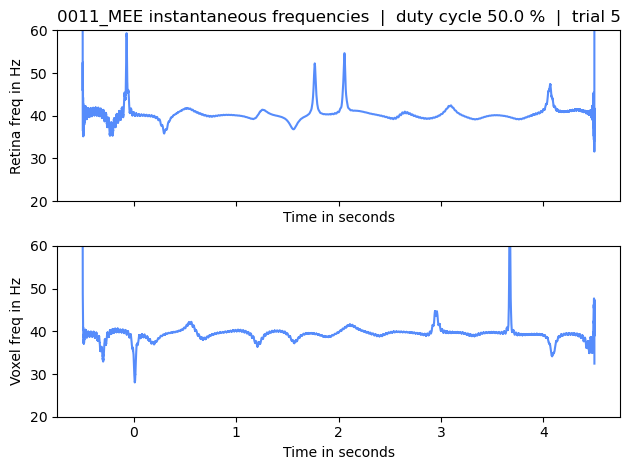

loading dataset for subject:  0012_C3Z


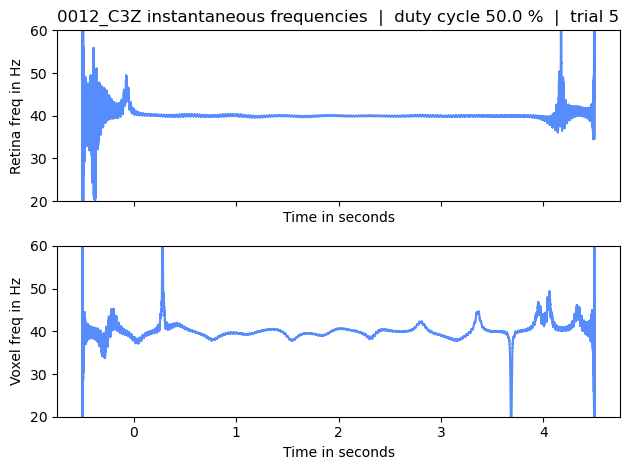

loading dataset for subject:  0014_TAG


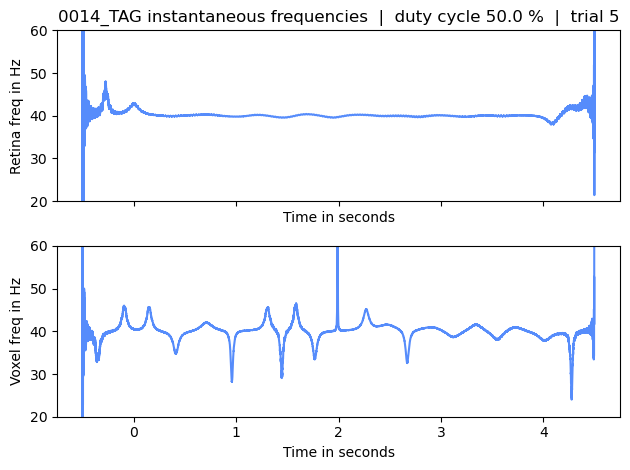

loading dataset for subject:  0015_QKW


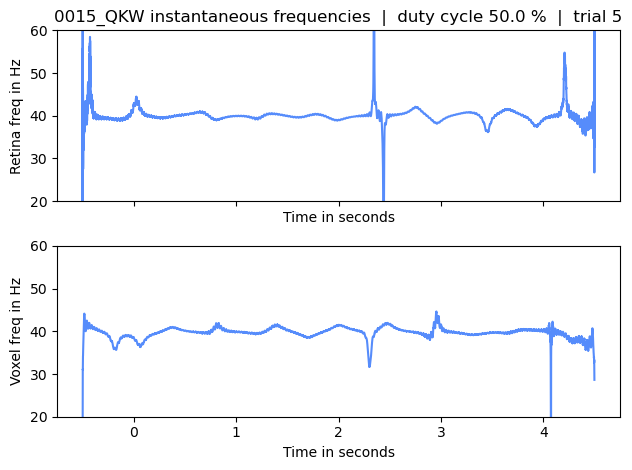

loading dataset for subject:  0016_XLZ


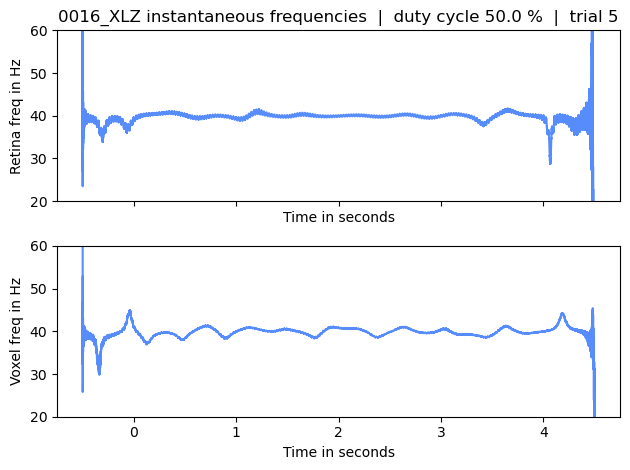

loading dataset for subject:  0017_QJ5


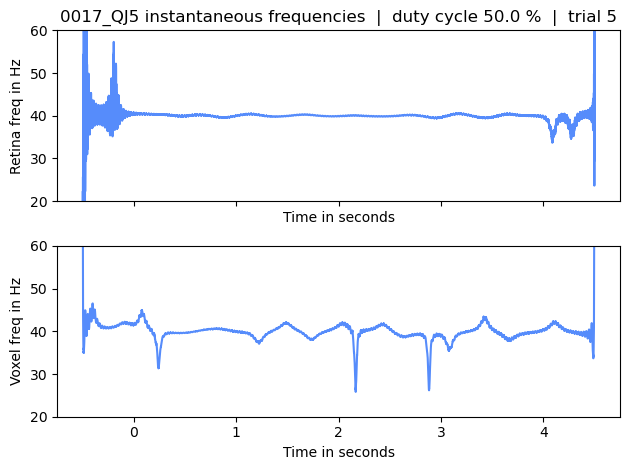

loading dataset for subject:  0018_5T3


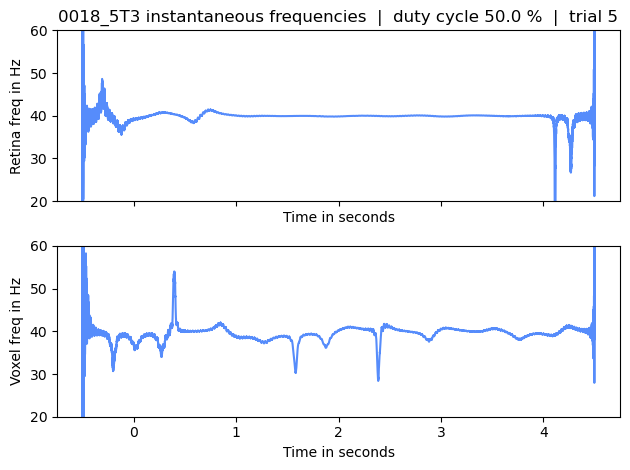

loading dataset for subject:  0019_COG


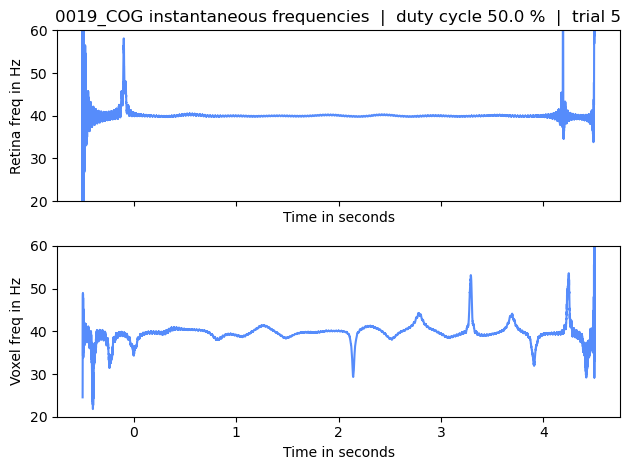

In [3]:
import random
for subject_index in ss['subject_idx_list']:
    # loop over each event type
    event_name = str(event_id)
    subjects_dir = ss['fs_subjects_dir']
    subject = ss['subject_id_list'][subject_index]
    print("loading dataset for subject: ", subject)

    save_dir = Path(ss['hilbert_dir']) / subject / event_name
    save_dir.mkdir(parents=True, exist_ok=True)

    stc_file = Path(ss['stc_dir']) / subject / event_name / f"{subject}-{trial}-vol.stc"

    stc = mne.read_source_estimate(stc_file)

    # hilbert transform the stc

    analytic_signal = hilbert(stc.data, axis=1)
    phase = np.angle(analytic_signal).astype(float)

    amplitude = np.abs(analytic_signal)

    median_amp = np.median(amplitude, axis=1)

    # pick the voxel with the highest median amplitude to be used as a reference instead of the retina one
    ref_voxel = np.argmax(median_amp)

    # read the retina csv
    retina_file = Path(ss['stc_dir']) / subject / event_name / f"{subject}-trial-{trial}-retina.csv"

    retina_df = pd.read_csv(retina_file)

    analytic_signal_retina = hilbert(retina_df["amplitude"])
    retina_phase = np.angle(analytic_signal_retina).astype(float)

    fs = 2000
    t = stc.times
    retina_instantaneous_phase = np.unwrap(np.angle(analytic_signal_retina))
    retina_instantaneous_frequency = np.diff(retina_instantaneous_phase) / (2.0*np.pi) * fs
    mean_vox_instantaneous_phase = np.unwrap(np.angle(analytic_signal[ref_voxel]))
    mean_vox_instantaneous_frequency = np.diff(mean_vox_instantaneous_phase) / (2.0*np.pi) * fs
    fig, (ax0, ax1) = plt.subplots(nrows=2, sharex='all', tight_layout=True)
    ax0.set_title(f"{subject} instantaneous frequencies  |  duty cycle {duty_cycle} %  |  trial {trial+1}")
    ax0.set(xlabel="Time in seconds", ylabel="Retina freq in Hz", ylim=(20, 60))
    ax0.plot(t[1:], retina_instantaneous_frequency)
    ax1.set(xlabel="Time in seconds", ylabel="Voxel freq in Hz", ylim=(20, 60))
    ax1.plot(t[1:], mean_vox_instantaneous_frequency)
    plt.show()